In [9]:
import sys
from pathlib import Path

sys.path.append(str(Path("../src").resolve()))

from green_function import *

import numpy as np
import matplotlib.pyplot as plt


In [13]:


# -------------------------------------------------
# Make the src folder importable
# -------------------------------------------------

PROJECT_ROOT = Path.cwd().resolve().parent
SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(
        0,
        str(SRC_DIR),
    )


# -------------------------------------------------
# Import the Green-function reconstruction
# -------------------------------------------------

from green_function import contour_reconstruction


# -------------------------------------------------
# Parameters
# -------------------------------------------------

N = 51
lam = 0.5
beta = 30.0

n_theta = 2048
margin = 0.2


# -------------------------------------------------
# Green-function reconstruction
# -------------------------------------------------

result = contour_reconstruction(
    N=N,
    lam=lam,
    beta=beta,
    n_theta=n_theta,
    margin=margin,
)


# -------------------------------------------------
# Main matrices
# -------------------------------------------------

C0_GF = result["C0_GF"]
delta_C_GF = result["delta_C_GF"]

C_GF = result["C_GF"]
C_diag = result["C_diag"]


# This is the central reconstruction equation:
#
#     C_GF = C0_GF + delta_C_GF
#

reconstruction_identity_error = np.max(
    np.abs(
        C_GF
        - (
            C0_GF
            + delta_C_GF
        )
    )
)


# -------------------------------------------------
# Numerical validation
# -------------------------------------------------

print("========== Green-function reconstruction ==========")

print(f"N        = {N}")
print(f"lambda   = {lam}")
print(f"beta     = {beta}")
print(f"n_theta  = {n_theta}")

print()

print(
    "Contour axes:"
)
print(
    f"horizontal = "
    f"{result['horizontal_axis']:.8f}"
)
print(
    f"vertical   = "
    f"{result['vertical_axis']:.8f}"
)

print()

print(
    "Internal reconstruction identity error:"
)
print(
    f"{reconstruction_identity_error:.6e}"
)

print()

print(
    "Reference matrix error "
    "||C0_GF - C0_diag||_max:"
)
print(
    f"{result['reference_max_abs_error']:.6e}"
)

print()

print(
    "Full matrix maximum error "
    "||C_GF - C_diag||_max:"
)
print(
    f"{result['max_abs_error']:.6e}"
)

print()

print(
    "Frobenius error:"
)
print(
    f"{result['frobenius_error']:.6e}"
)

print()

print(
    "Relative Frobenius error:"
)
print(
    f"{result['relative_frobenius_error']:.6e}"
)

print()

print(
    "Largest residual imaginary part:"
)
print(
    f"{result['max_imaginary_part']:.6e}"
)

print()

print(
    "Selected element comparison for pair (0, 1):"
)

print(
    "C_GF[0, 1]   =",
    np.real_if_close(
        C_GF[0, 1]
    ),
)

print(
    "C_diag[0, 1] =",
    C_diag[0, 1],
)

print(
    "difference   =",
    C_GF[0, 1] - C_diag[0, 1],
)

========== Green-function reconstruction ==========
N        = 51
lambda   = 0.5
beta     = 30.0
n_theta  = 2048

Contour axes:
horizontal = 2.19750785
vertical   = 0.05235988

Internal reconstruction identity error:
0.000000e+00

Reference matrix error ||C0_GF - C0_diag||_max:
1.759520e-14

Full matrix maximum error ||C_GF - C_diag||_max:
5.330641e-15

Frobenius error:
2.361002e-14

Relative Frobenius error:
4.698569e-15

Largest residual imaginary part:
3.179370e-16

Selected element comparison for pair (0, 1):
C_GF[0, 1]   = -0.1560028295037266
C_diag[0, 1] = -0.15600282950372682
difference   = (2.220446049250313e-16+2.7412768209951968e-17j)


In [2]:
lam = 0.5

result = compute_deltaC_decomposition(
    N=51,
    lam=lam,
    beta=30,
)

delta_total = result["delta_total"]

delta_zero = result["delta_zero"]

delta_regular = result["delta_regular"]

print(
    np.max(
        np.abs(
            delta_total
            -
            delta_zero
            -
            delta_regular
        )
    )
)

0.0


In [4]:
print(result["E_zero"])
print(result["E_zero_ref"])

-9.44249045323675e-13
-3.962149129780494e-18


In [3]:
pair = (0,1)

i,j = pair

print(delta_total[i,j])

print(delta_zero[i,j])

print(delta_regular[i,j])

print(
    delta_total[i,j]
    -
    delta_zero[i,j]
    -
    delta_regular[i,j]
)

(0.00831569816122096-1.673090184460853e-17j)
-3.7769408344423487e-13
(0.008315698161598654-1.673090184460853e-17j)
0j


In [6]:
# ============================================================
# Lambda scan for the Green-function correction decomposition
# ============================================================

N = 51
beta = 30.0

# Başlangıçta çok yoğun seçmeyelim.
# Contour integral her lambda için yeniden hesaplandığı için maliyetli olabilir.
lambda_values = np.linspace(-1.0, 1.0, 81)

pairs = [
    (0, 1),
    (12, 13),
    (24, 25),
    (0, 50),
]


# Her pair için sonuçları saklayacağımız sözlük
pair_results = {
    pair: {
        "total": [],
        "zero": [],
        "regular": [],
    }
    for pair in pairs
}


for index, lam in enumerate(lambda_values):

    print(
        f"\rComputing lambda {index + 1}/{len(lambda_values)}: "
        f"{lam:.3f}",
        end="",
    )

    result = compute_deltaC_decomposition(
        N=N,
        lam=lam,
        beta=beta,
        n_theta=512,
        margin=0.2,
    )

    delta_total = result["delta_total"]
    delta_zero = result["delta_zero"]
    delta_regular = result["delta_regular"]

    for pair in pairs:

        i, j = pair

        pair_results[pair]["total"].append(
            np.real_if_close(delta_total[i, j]).real
        )

        pair_results[pair]["zero"].append(
            np.real_if_close(delta_zero[i, j]).real
        )

        pair_results[pair]["regular"].append(
            np.real_if_close(delta_regular[i, j]).real
        )


print("\nLambda scan completed.")


# Listeleri NumPy array'lerine çevir
for pair in pairs:
    for contribution in ["total", "zero", "regular"]:
        pair_results[pair][contribution] = np.asarray(
            pair_results[pair][contribution],
            dtype=float,
        )

Computing lambda 81/81: 1.0005
Lambda scan completed.


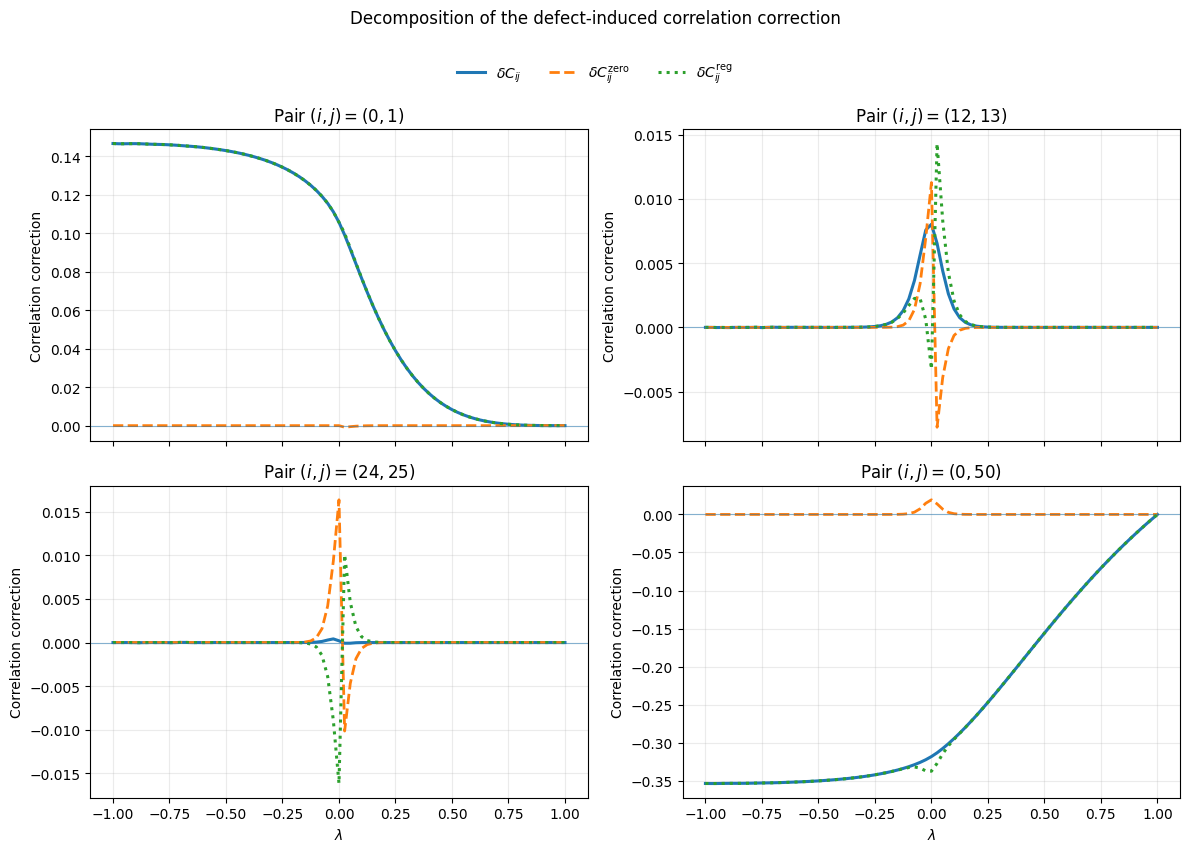

In [10]:
# ============================================================
# Plot delta C = delta C_zero + delta C_regular
# ============================================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 8),
    sharex=True,
)

axes = axes.ravel()


for ax, pair in zip(axes, pairs):

    total = pair_results[pair]["total"]
    zero = pair_results[pair]["zero"]
    regular = pair_results[pair]["regular"]

    ax.plot(
        lambda_values,
        total,
        linewidth=2.2,
        label=r"$\delta C_{ij}$",
    )

    ax.plot(
        lambda_values,
        zero,
        linestyle="--",
        linewidth=2.0,
        label=r"$\delta C_{ij}^{\mathrm{zero}}$",
    )

    ax.plot(
        lambda_values,
        regular,
        linestyle=":",
        linewidth=2.2,
        label=r"$\delta C_{ij}^{\mathrm{reg}}$",
    )

    ax.axhline(
        0.0,
        linewidth=0.8,
        alpha=0.5,
    )

    ax.set_title(
        rf"Pair $(i,j)=({pair[0]},{pair[1]})$"
    )

    ax.set_ylabel(
        r"Correlation correction"
    )

    ax.grid(
        alpha=0.25
    )


# Sadece alt subplotlarda x etiketi
axes[2].set_xlabel(r"$\lambda$")
axes[3].set_xlabel(r"$\lambda$")


# Tek ortak legend
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=3,
    frameon=False,
    bbox_to_anchor=(0.5, 1.01),
)


fig.suptitle(
    r"Decomposition of the defect-induced correlation correction",
    y=1.06,
)

fig.tight_layout()

plt.show()